In [5]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# Data Collection

In [6]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "15m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

# Technical Indicators

### Momentum

In [7]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [8]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [9]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [10]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

# Data Cleaning

In [11]:
dataset = df.copy()
dataset = DataCleaning(dataset).clean_data()

# Feature Engineering

### Timestamp Features

In [12]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

### Lag Features (Targets)

In [13]:
def create_targets(df, target_column='close', n_steps=16):
    
    for step in range(1, n_steps + 1):
        df[f'close_step_{step}'] = df[target_column].shift(-step)
    
    return df

In [14]:
dataset = create_targets(dataset, target_column='close', n_steps=16)

In [15]:
dataset = DataCleaning(dataset).clean_data()

# Feature Selection

In [16]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [17]:
dataset = dataset.sort_values('timestamp')

In [18]:
TARGET = ['close_step_1', 'close_step_2', 'close_step_3', 'close_step_4', 'close_step_5', 'close_step_6', 'close_step_7', 'close_step_8', 'close_step_9', 'close_step_10', 'close_step_11', 'close_step_12', 'close_step_13', 'close_step_14', 'close_step_15', 'close_step_16']
DROP_COLUMNS = ['timestamp'] + TARGET

In [19]:
def X_y_split(df, target='', drop_columns=[]):
    X = dataset.drop(columns=drop_columns)
    y = dataset[target]
    return X, y

### Feature Importance

In [34]:
xgb_close = XGBRegressor(
    eval_metric="rmse",
    early_stopping_rounds=100,
    device='cuda', 
    max_bin=256 
)

In [35]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [36]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum


### Feature importance for all the targets

In [37]:
features_by_target = {}
for target in TARGET:
    print(f'Feature importance for {target}')
    X, y = X_y_split(dataset, target=target, drop_columns=DROP_COLUMNS)
    fold_metrics, oof_pred, gain_accum = model_training(X, y, xgb_close, tscv)
    importance_df = (
        gain_accum.div(100)             # average gain across folds
        .sort_values(ascending=False)
        .rename("avg_gain")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100
    features_by_target[target] = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()


Feature importance for close_step_1
Feature importance for close_step_2
Feature importance for close_step_3
Feature importance for close_step_4
Feature importance for close_step_5
Feature importance for close_step_6
Feature importance for close_step_7
Feature importance for close_step_8
Feature importance for close_step_9
Feature importance for close_step_10
Feature importance for close_step_11
Feature importance for close_step_12
Feature importance for close_step_13
Feature importance for close_step_14
Feature importance for close_step_15
Feature importance for close_step_16


# Hyperparameter Tuning

In [38]:
params = {
    "n_estimators": [200, 500, 800, 1000],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10, 15],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.5, 1, 1.5, 2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0, 1, 5, 10],
    "reg_alpha": [0, 0.5, 1, 5]
}

In [39]:
cutoff_date = dataset['timestamp'].quantile(0.8)
close_train = dataset[dataset['timestamp'] < cutoff_date]
close_test = dataset[dataset['timestamp'] >= cutoff_date]

In [42]:
hyperparameter_tuning = RandomizedSearchCV(
    xgb_close, 
    param_distributions=params, 
    n_iter=10, 
    scoring='neg_root_mean_squared_error', 
    cv=tscv, 
    verbose=3,
    n_jobs=2
)

In [43]:
parameters_by_target = {}
for target in TARGET:
    X_close_train = close_train[features_by_target[target]]
    y_close_train = close_train[target]

    split_point = int(len(X_close_train) * 0.8)
    X_train_split = X_close_train[:split_point]
    y_train_split = y_close_train[:split_point]
    X_val_split = X_close_train[split_point:]
    y_val_split = y_close_train[split_point:]

    hyperparameter_tuning.fit(
        X_train_split, 
        y_train_split,
        eval_set=[(X_val_split, y_val_split)],
        verbose=False
    )

    print(f'Best parameters for {target}: {hyperparameter_tuning.best_params_}')
    parameters_by_target[target] = hyperparameter_tuning.best_params_

Fitting 100 folds for each of 10 candidates, totalling 1000 fits
Best parameters for close_step_1: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0.5, 'n_estimators': 800, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.6}
Fitting 100 folds for each of 10 candidates, totalling 1000 fits
Best parameters for close_step_2: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.6}
Fitting 100 folds for each of 10 candidates, totalling 1000 fits
Best parameters for close_step_3: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'n_estimators': 800, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 1.0}
Fitting 100 folds for each of 10 candidates, totalling 1000 fits
Best parameters for close_step_4: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 1000, '

In [44]:
parameters_by_target

{'close_step_1': {'subsample': 1.0,
  'reg_lambda': 0,
  'reg_alpha': 0.5,
  'n_estimators': 800,
  'min_child_weight': 10,
  'max_depth': 5,
  'learning_rate': 0.1,
  'gamma': 0.5,
  'colsample_bytree': 0.6},
 'close_step_2': {'subsample': 0.8,
  'reg_lambda': 10,
  'reg_alpha': 0.5,
  'n_estimators': 1000,
  'min_child_weight': 10,
  'max_depth': 3,
  'learning_rate': 0.01,
  'gamma': 0.5,
  'colsample_bytree': 0.6},
 'close_step_3': {'subsample': 1.0,
  'reg_lambda': 0,
  'reg_alpha': 1,
  'n_estimators': 800,
  'min_child_weight': 10,
  'max_depth': 3,
  'learning_rate': 0.1,
  'gamma': 1,
  'colsample_bytree': 1.0},
 'close_step_4': {'subsample': 0.6,
  'reg_lambda': 1,
  'reg_alpha': 0.5,
  'n_estimators': 1000,
  'min_child_weight': 10,
  'max_depth': 5,
  'learning_rate': 0.01,
  'gamma': 0,
  'colsample_bytree': 0.6},
 'close_step_5': {'subsample': 0.8,
  'reg_lambda': 0,
  'reg_alpha': 0.5,
  'n_estimators': 1000,
  'min_child_weight': 5,
  'max_depth': 3,
  'learning_rate': 

# Train the models

In [46]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [47]:
import joblib
import pickle
import json
import os
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)

[0]	validation_0-rmse:14500.71571
[1]	validation_0-rmse:13054.21988
[2]	validation_0-rmse:11752.89661
[3]	validation_0-rmse:10581.65408
[4]	validation_0-rmse:9526.68162
[5]	validation_0-rmse:8578.90066
[6]	validation_0-rmse:7724.95311
[7]	validation_0-rmse:6955.59325
[8]	validation_0-rmse:6262.50794
[9]	validation_0-rmse:5640.18966
[10]	validation_0-rmse:5078.70731
[11]	validation_0-rmse:4574.10452
[12]	validation_0-rmse:4119.37567
[13]	validation_0-rmse:3710.39744
[14]	validation_0-rmse:3342.81889
[15]	validation_0-rmse:3011.07161
[16]	validation_0-rmse:2713.05134
[17]	validation_0-rmse:2445.40206
[18]	validation_0-rmse:2204.59626
[19]	validation_0-rmse:1987.56833
[20]	validation_0-rmse:1793.08021
[21]	validation_0-rmse:1617.85587
[22]	validation_0-rmse:1460.37898
[23]	validation_0-rmse:1319.11016
[24]	validation_0-rmse:1192.35523
[25]	validation_0-rmse:1078.75647
[26]	validation_0-rmse:977.15593
[27]	validation_0-rmse:886.29946
[28]	validation_0-rmse:805.41345
[29]	validation_0-rmse:

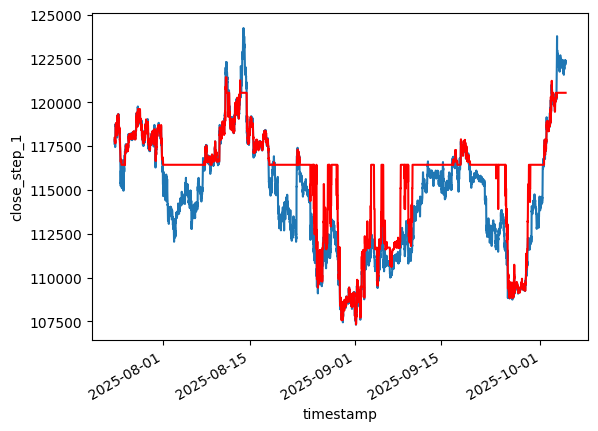

[0]	validation_0-rmse:15953.99126
[1]	validation_0-rmse:15802.29203
[2]	validation_0-rmse:15651.72396
[3]	validation_0-rmse:15503.28756
[4]	validation_0-rmse:15357.32653
[5]	validation_0-rmse:15211.93015
[6]	validation_0-rmse:15067.53319
[7]	validation_0-rmse:14925.55013
[8]	validation_0-rmse:14784.55525
[9]	validation_0-rmse:14644.22199
[10]	validation_0-rmse:14505.03699
[11]	validation_0-rmse:14369.70248
[12]	validation_0-rmse:14235.76456
[13]	validation_0-rmse:14100.38146
[14]	validation_0-rmse:13965.83405
[15]	validation_0-rmse:13835.78435
[16]	validation_0-rmse:13708.13074
[17]	validation_0-rmse:13577.86077
[18]	validation_0-rmse:13448.36541
[19]	validation_0-rmse:13320.47239
[20]	validation_0-rmse:13198.12440
[21]	validation_0-rmse:13072.37676
[22]	validation_0-rmse:12952.13133
[23]	validation_0-rmse:12829.36378
[24]	validation_0-rmse:12706.73581
[25]	validation_0-rmse:12585.70633
[26]	validation_0-rmse:12465.03348
[27]	validation_0-rmse:12345.74236
[28]	validation_0-rmse:12227.3

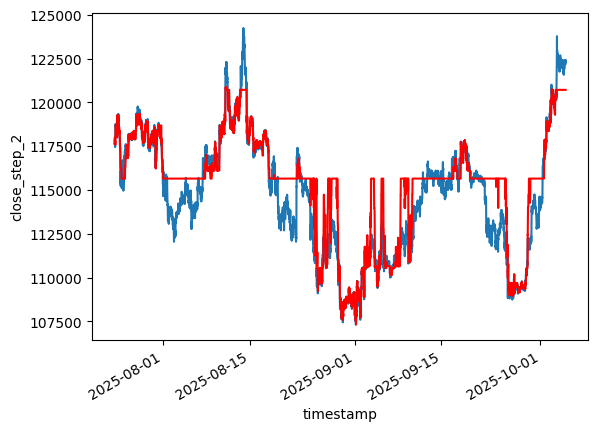

[0]	validation_0-rmse:14570.03886
[1]	validation_0-rmse:13181.23120
[2]	validation_0-rmse:11964.08245
[3]	validation_0-rmse:10812.13439
[4]	validation_0-rmse:9765.84814
[5]	validation_0-rmse:8855.75096
[6]	validation_0-rmse:7991.72769
[7]	validation_0-rmse:7214.66534
[8]	validation_0-rmse:6523.77436
[9]	validation_0-rmse:5888.23038
[10]	validation_0-rmse:5317.68834
[11]	validation_0-rmse:4808.58874
[12]	validation_0-rmse:4355.82921
[13]	validation_0-rmse:3954.08745
[14]	validation_0-rmse:3576.27149
[15]	validation_0-rmse:3237.33359
[16]	validation_0-rmse:2936.39057
[17]	validation_0-rmse:2669.62190
[18]	validation_0-rmse:2420.28812
[19]	validation_0-rmse:2204.38673
[20]	validation_0-rmse:2011.44668
[21]	validation_0-rmse:1830.39941
[22]	validation_0-rmse:1668.08308
[23]	validation_0-rmse:1529.19459
[24]	validation_0-rmse:1394.75107
[25]	validation_0-rmse:1284.61722
[26]	validation_0-rmse:1177.00413
[27]	validation_0-rmse:1082.90139
[28]	validation_0-rmse:996.64181
[29]	validation_0-rms

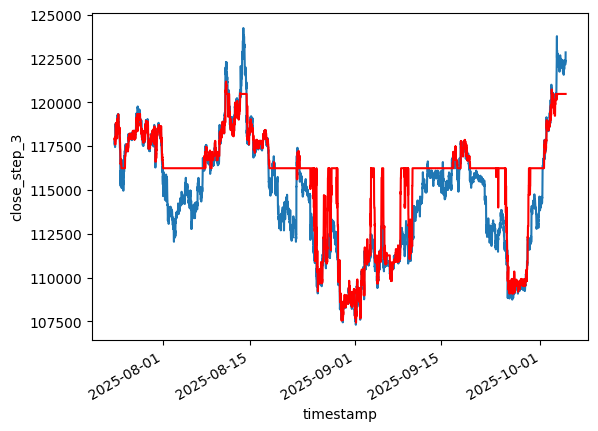

[0]	validation_0-rmse:15946.51727
[1]	validation_0-rmse:15787.77375
[2]	validation_0-rmse:15630.93646
[3]	validation_0-rmse:15475.23929
[4]	validation_0-rmse:15321.39552
[5]	validation_0-rmse:15169.18354
[6]	validation_0-rmse:15018.33593
[7]	validation_0-rmse:14869.15076
[8]	validation_0-rmse:14721.49581
[9]	validation_0-rmse:14575.11122
[10]	validation_0-rmse:14430.21241
[11]	validation_0-rmse:14286.73188
[12]	validation_0-rmse:14144.68913
[13]	validation_0-rmse:14004.19913
[14]	validation_0-rmse:13864.97102
[15]	validation_0-rmse:13727.23016
[16]	validation_0-rmse:13590.74492
[17]	validation_0-rmse:13455.63635
[18]	validation_0-rmse:13321.78955
[19]	validation_0-rmse:13189.30515
[20]	validation_0-rmse:13058.37243
[21]	validation_0-rmse:12928.61670
[22]	validation_0-rmse:12800.13263
[23]	validation_0-rmse:12673.13315
[24]	validation_0-rmse:12547.49870
[25]	validation_0-rmse:12423.00425
[26]	validation_0-rmse:12299.87085
[27]	validation_0-rmse:12177.83131
[28]	validation_0-rmse:12056.7

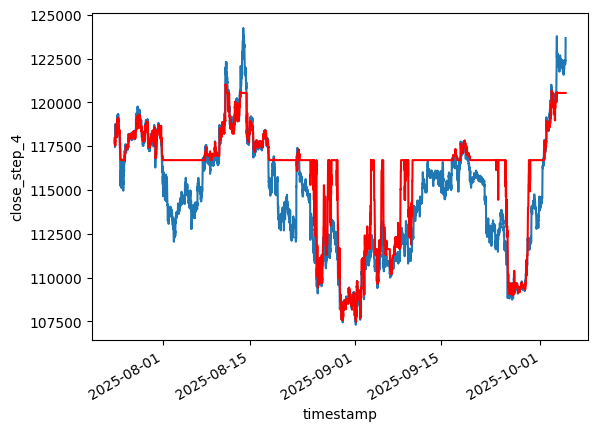

[0]	validation_0-rmse:15952.90331
[1]	validation_0-rmse:15800.42220
[2]	validation_0-rmse:15649.03331
[3]	validation_0-rmse:15500.26282
[4]	validation_0-rmse:15353.43180
[5]	validation_0-rmse:15207.23245
[6]	validation_0-rmse:15061.79294
[7]	validation_0-rmse:14919.27031
[8]	validation_0-rmse:14778.08675
[9]	validation_0-rmse:14637.40255
[10]	validation_0-rmse:14497.51908
[11]	validation_0-rmse:14361.74222
[12]	validation_0-rmse:14225.05950
[13]	validation_0-rmse:14089.00661
[14]	validation_0-rmse:13953.62449
[15]	validation_0-rmse:13823.22507
[16]	validation_0-rmse:13690.82084
[17]	validation_0-rmse:13563.89039
[18]	validation_0-rmse:13433.81001
[19]	validation_0-rmse:13304.98246
[20]	validation_0-rmse:13182.22129
[21]	validation_0-rmse:13056.30469
[22]	validation_0-rmse:12935.65036
[23]	validation_0-rmse:12811.30914
[24]	validation_0-rmse:12689.34284
[25]	validation_0-rmse:12572.20129
[26]	validation_0-rmse:12451.01668
[27]	validation_0-rmse:12336.40440
[28]	validation_0-rmse:12217.6

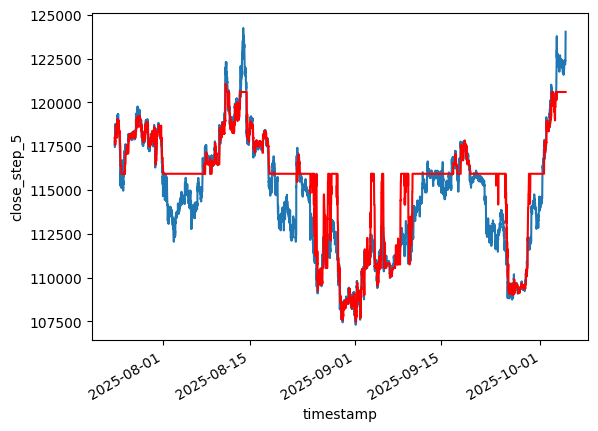

[0]	validation_0-rmse:14523.28410
[1]	validation_0-rmse:13094.25214
[2]	validation_0-rmse:11818.29054
[3]	validation_0-rmse:10657.23311
[4]	validation_0-rmse:9614.66485
[5]	validation_0-rmse:8673.44668
[6]	validation_0-rmse:7824.11041
[7]	validation_0-rmse:7062.90815
[8]	validation_0-rmse:6376.23813
[9]	validation_0-rmse:5756.68344
[10]	validation_0-rmse:5198.61816
[11]	validation_0-rmse:4696.67279
[12]	validation_0-rmse:4246.08947
[13]	validation_0-rmse:3838.78918
[14]	validation_0-rmse:3473.72316
[15]	validation_0-rmse:3144.59067
[16]	validation_0-rmse:2845.02027
[17]	validation_0-rmse:2580.14356
[18]	validation_0-rmse:2338.63959
[19]	validation_0-rmse:2120.27248
[20]	validation_0-rmse:1928.11087
[21]	validation_0-rmse:1754.49891
[22]	validation_0-rmse:1598.70102
[23]	validation_0-rmse:1457.76947
[24]	validation_0-rmse:1332.46467
[25]	validation_0-rmse:1222.11950
[26]	validation_0-rmse:1121.41530
[27]	validation_0-rmse:1033.41442
[28]	validation_0-rmse:954.73448
[29]	validation_0-rms

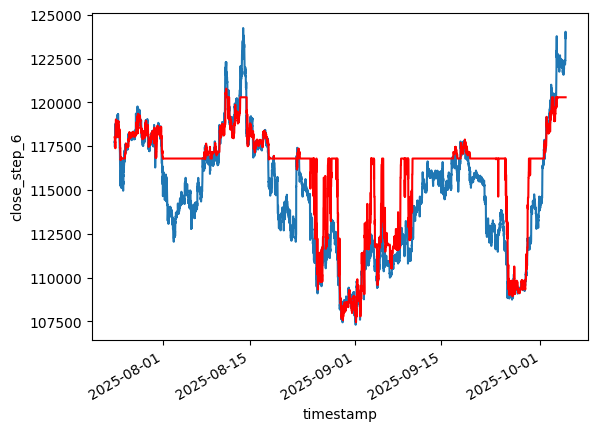

[0]	validation_0-rmse:15340.76615
[1]	validation_0-rmse:14615.83814
[2]	validation_0-rmse:13919.92456
[3]	validation_0-rmse:13255.53519
[4]	validation_0-rmse:12647.48102
[5]	validation_0-rmse:12039.85775
[6]	validation_0-rmse:11466.85080
[7]	validation_0-rmse:10945.05563
[8]	validation_0-rmse:10416.31407
[9]	validation_0-rmse:9925.97632
[10]	validation_0-rmse:9444.18693
[11]	validation_0-rmse:9013.13192
[12]	validation_0-rmse:8576.58366
[13]	validation_0-rmse:8161.78163
[14]	validation_0-rmse:7767.53973
[15]	validation_0-rmse:7404.92320
[16]	validation_0-rmse:7046.72732
[17]	validation_0-rmse:6710.25301
[18]	validation_0-rmse:6385.85871
[19]	validation_0-rmse:6080.69250
[20]	validation_0-rmse:5802.85768
[21]	validation_0-rmse:5526.07381
[22]	validation_0-rmse:5265.25859
[23]	validation_0-rmse:5012.88571
[24]	validation_0-rmse:4773.17432
[25]	validation_0-rmse:4547.73241
[26]	validation_0-rmse:4338.17624
[27]	validation_0-rmse:4140.83179
[28]	validation_0-rmse:3944.74385
[29]	validation

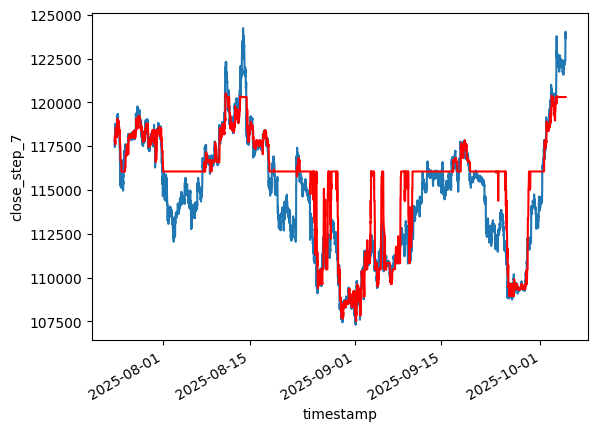

[0]	validation_0-rmse:15342.57025
[1]	validation_0-rmse:14621.15413
[2]	validation_0-rmse:13928.84064
[3]	validation_0-rmse:13267.58803
[4]	validation_0-rmse:12640.11813
[5]	validation_0-rmse:12034.70015
[6]	validation_0-rmse:11483.83300
[7]	validation_0-rmse:10961.93628
[8]	validation_0-rmse:10436.40773
[9]	validation_0-rmse:9943.56423
[10]	validation_0-rmse:9462.30854
[11]	validation_0-rmse:9030.76199
[12]	validation_0-rmse:8594.75466
[13]	validation_0-rmse:8180.35627
[14]	validation_0-rmse:7786.31527
[15]	validation_0-rmse:7416.13001
[16]	validation_0-rmse:7058.28706
[17]	validation_0-rmse:6732.39690
[18]	validation_0-rmse:6409.45099
[19]	validation_0-rmse:6101.67122
[20]	validation_0-rmse:5810.24512
[21]	validation_0-rmse:5538.78169
[22]	validation_0-rmse:5285.75281
[23]	validation_0-rmse:5033.56189
[24]	validation_0-rmse:4793.43537
[25]	validation_0-rmse:4573.11284
[26]	validation_0-rmse:4356.56520
[27]	validation_0-rmse:4152.45259
[28]	validation_0-rmse:3956.62167
[29]	validation

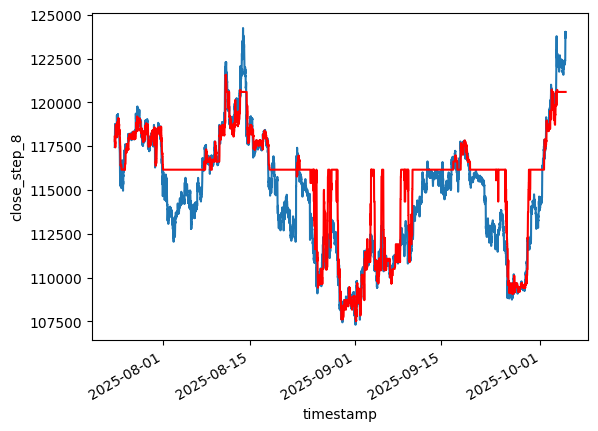

[0]	validation_0-rmse:15953.57510
[1]	validation_0-rmse:15802.80643
[2]	validation_0-rmse:15653.38254
[3]	validation_0-rmse:15505.74397
[4]	validation_0-rmse:15359.92112
[5]	validation_0-rmse:15214.63275
[6]	validation_0-rmse:15070.38820
[7]	validation_0-rmse:14928.80510
[8]	validation_0-rmse:14787.46187
[9]	validation_0-rmse:14649.29966
[10]	validation_0-rmse:14510.46747
[11]	validation_0-rmse:14375.26552
[12]	validation_0-rmse:14238.81288
[13]	validation_0-rmse:14106.44441
[14]	validation_0-rmse:13971.74452
[15]	validation_0-rmse:13843.12836
[16]	validation_0-rmse:13712.18267
[17]	validation_0-rmse:13582.06921
[18]	validation_0-rmse:13452.66770
[19]	validation_0-rmse:13324.51123
[20]	validation_0-rmse:13202.27131
[21]	validation_0-rmse:13076.96908
[22]	validation_0-rmse:12955.64755
[23]	validation_0-rmse:12831.99899
[24]	validation_0-rmse:12714.53980
[25]	validation_0-rmse:12593.40451
[26]	validation_0-rmse:12472.96628
[27]	validation_0-rmse:12353.85687
[28]	validation_0-rmse:12235.7

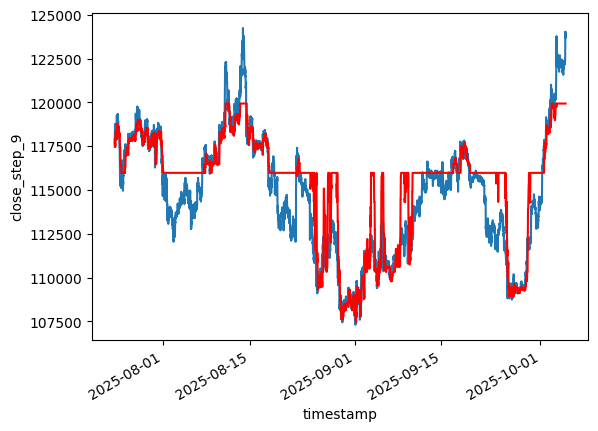

[0]	validation_0-rmse:15342.40265
[1]	validation_0-rmse:14614.11241
[2]	validation_0-rmse:13929.96159
[3]	validation_0-rmse:13264.33982
[4]	validation_0-rmse:12654.51769
[5]	validation_0-rmse:12047.90241
[6]	validation_0-rmse:11476.48284
[7]	validation_0-rmse:10926.66231
[8]	validation_0-rmse:10427.98773
[9]	validation_0-rmse:9923.53724
[10]	validation_0-rmse:9442.10554
[11]	validation_0-rmse:9008.21544
[12]	validation_0-rmse:8571.70482
[13]	validation_0-rmse:8167.68876
[14]	validation_0-rmse:7772.84352
[15]	validation_0-rmse:7399.19425
[16]	validation_0-rmse:7041.64232
[17]	validation_0-rmse:6702.55575
[18]	validation_0-rmse:6381.98578
[19]	validation_0-rmse:6085.76440
[20]	validation_0-rmse:5792.64476
[21]	validation_0-rmse:5514.98682
[22]	validation_0-rmse:5251.81497
[23]	validation_0-rmse:5008.49898
[24]	validation_0-rmse:4769.31217
[25]	validation_0-rmse:4545.13761
[26]	validation_0-rmse:4337.89828
[27]	validation_0-rmse:4132.62401
[28]	validation_0-rmse:3942.22359
[29]	validation

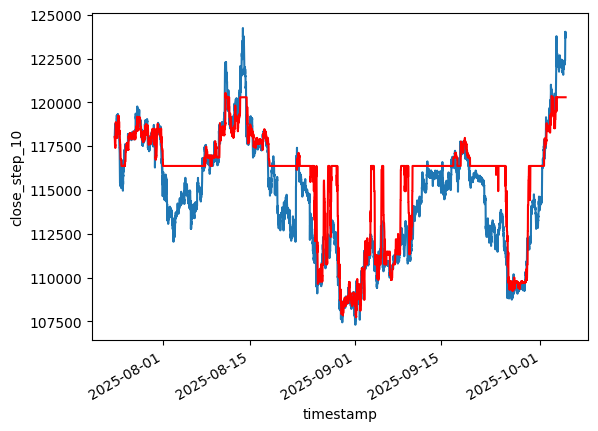

[0]	validation_0-rmse:14576.60210
[1]	validation_0-rmse:13192.37825
[2]	validation_0-rmse:11930.25960
[3]	validation_0-rmse:10790.16877
[4]	validation_0-rmse:9741.10554
[5]	validation_0-rmse:8848.37745
[6]	validation_0-rmse:7987.54107
[7]	validation_0-rmse:7251.73980
[8]	validation_0-rmse:6547.76927
[9]	validation_0-rmse:5922.97781
[10]	validation_0-rmse:5358.59134
[11]	validation_0-rmse:4858.66990
[12]	validation_0-rmse:4404.42591
[13]	validation_0-rmse:4009.13153
[14]	validation_0-rmse:3630.43473
[15]	validation_0-rmse:3291.53676
[16]	validation_0-rmse:2987.13896
[17]	validation_0-rmse:2719.38023
[18]	validation_0-rmse:2476.25901
[19]	validation_0-rmse:2262.28579
[20]	validation_0-rmse:2065.84661
[21]	validation_0-rmse:1894.07766
[22]	validation_0-rmse:1741.32228
[23]	validation_0-rmse:1602.11872
[24]	validation_0-rmse:1480.41248
[25]	validation_0-rmse:1373.62725
[26]	validation_0-rmse:1277.05017
[27]	validation_0-rmse:1187.03819
[28]	validation_0-rmse:1107.87379
[29]	validation_0-rm

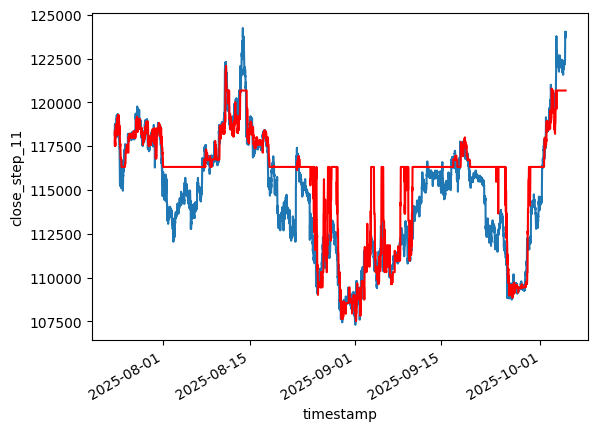

[0]	validation_0-rmse:15341.47761
[1]	validation_0-rmse:14616.47411
[2]	validation_0-rmse:13921.41833
[3]	validation_0-rmse:13258.94874
[4]	validation_0-rmse:12648.06992
[5]	validation_0-rmse:12041.90315
[6]	validation_0-rmse:11465.41093
[7]	validation_0-rmse:10943.71279
[8]	validation_0-rmse:10416.53496
[9]	validation_0-rmse:9910.62194
[10]	validation_0-rmse:9450.86029
[11]	validation_0-rmse:8991.93242
[12]	validation_0-rmse:8557.27207
[13]	validation_0-rmse:8167.53841
[14]	validation_0-rmse:7772.71505
[15]	validation_0-rmse:7401.19990
[16]	validation_0-rmse:7043.38755
[17]	validation_0-rmse:6712.16367
[18]	validation_0-rmse:6389.38861
[19]	validation_0-rmse:6082.36527
[20]	validation_0-rmse:5793.83158
[21]	validation_0-rmse:5525.51675
[22]	validation_0-rmse:5272.72322
[23]	validation_0-rmse:5020.00444
[24]	validation_0-rmse:4783.15339
[25]	validation_0-rmse:4556.41867
[26]	validation_0-rmse:4342.19676
[27]	validation_0-rmse:4145.93292
[28]	validation_0-rmse:3950.57895
[29]	validation

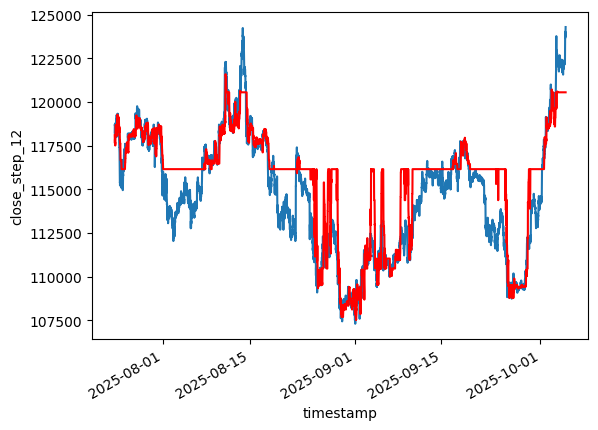

[0]	validation_0-rmse:14583.07311
[1]	validation_0-rmse:13198.68991
[2]	validation_0-rmse:11945.23717
[3]	validation_0-rmse:10806.91522
[4]	validation_0-rmse:9763.00026
[5]	validation_0-rmse:8870.89275
[6]	validation_0-rmse:8012.62907
[7]	validation_0-rmse:7237.63109
[8]	validation_0-rmse:6560.95313
[9]	validation_0-rmse:5935.67983
[10]	validation_0-rmse:5367.48138
[11]	validation_0-rmse:4856.91747
[12]	validation_0-rmse:4406.65902
[13]	validation_0-rmse:3997.50514
[14]	validation_0-rmse:3633.04195
[15]	validation_0-rmse:3310.50921
[16]	validation_0-rmse:3006.20853
[17]	validation_0-rmse:2742.56114
[18]	validation_0-rmse:2497.60469
[19]	validation_0-rmse:2279.44291
[20]	validation_0-rmse:2085.88848
[21]	validation_0-rmse:1917.71519
[22]	validation_0-rmse:1765.45250
[23]	validation_0-rmse:1624.66760
[24]	validation_0-rmse:1501.98068
[25]	validation_0-rmse:1390.97407
[26]	validation_0-rmse:1294.74285
[27]	validation_0-rmse:1208.20962
[28]	validation_0-rmse:1131.55465
[29]	validation_0-rm

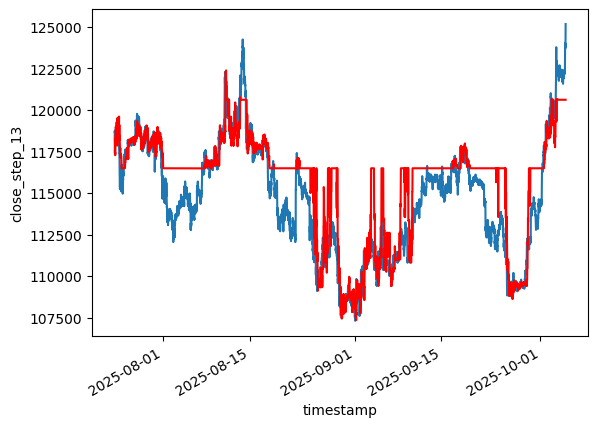

[0]	validation_0-rmse:15344.86169
[1]	validation_0-rmse:14616.25372
[2]	validation_0-rmse:13929.06063
[3]	validation_0-rmse:13269.09202
[4]	validation_0-rmse:12637.48338
[5]	validation_0-rmse:12057.94891
[6]	validation_0-rmse:11482.06174
[7]	validation_0-rmse:10931.59786
[8]	validation_0-rmse:10400.52609
[9]	validation_0-rmse:9923.43555
[10]	validation_0-rmse:9445.65220
[11]	validation_0-rmse:9008.94454
[12]	validation_0-rmse:8573.54474
[13]	validation_0-rmse:8160.78015
[14]	validation_0-rmse:7766.12385
[15]	validation_0-rmse:7406.54508
[16]	validation_0-rmse:7048.93966
[17]	validation_0-rmse:6713.10128
[18]	validation_0-rmse:6408.50786
[19]	validation_0-rmse:6103.52415
[20]	validation_0-rmse:5812.21581
[21]	validation_0-rmse:5536.03210
[22]	validation_0-rmse:5283.23435
[23]	validation_0-rmse:5032.02806
[24]	validation_0-rmse:4795.33194
[25]	validation_0-rmse:4578.06105
[26]	validation_0-rmse:4364.86473
[27]	validation_0-rmse:4172.60118
[28]	validation_0-rmse:3976.92659
[29]	validation

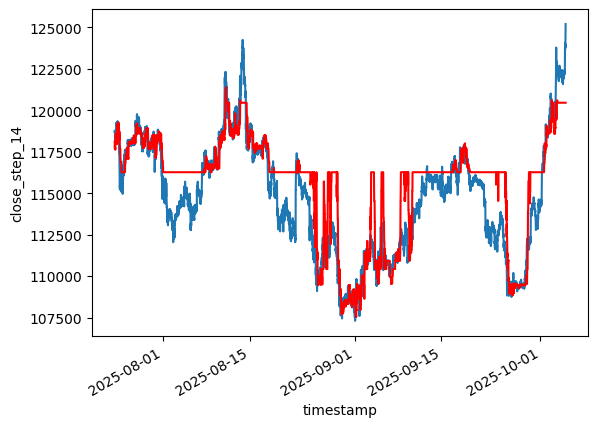

[0]	validation_0-rmse:15953.79149
[1]	validation_0-rmse:15802.24633
[2]	validation_0-rmse:15652.59844
[3]	validation_0-rmse:15504.10284
[4]	validation_0-rmse:15357.12508
[5]	validation_0-rmse:15211.74439
[6]	validation_0-rmse:15068.02430
[7]	validation_0-rmse:14925.49365
[8]	validation_0-rmse:14783.59859
[9]	validation_0-rmse:14644.83611
[10]	validation_0-rmse:14505.60521
[11]	validation_0-rmse:14367.45525
[12]	validation_0-rmse:14232.23254
[13]	validation_0-rmse:14097.32127
[14]	validation_0-rmse:13962.29206
[15]	validation_0-rmse:13828.88801
[16]	validation_0-rmse:13696.95881
[17]	validation_0-rmse:13569.22478
[18]	validation_0-rmse:13442.52827
[19]	validation_0-rmse:13314.09704
[20]	validation_0-rmse:13187.04685
[21]	validation_0-rmse:13060.84825
[22]	validation_0-rmse:12940.34777
[23]	validation_0-rmse:12817.64825
[24]	validation_0-rmse:12694.45462
[25]	validation_0-rmse:12572.51968
[26]	validation_0-rmse:12456.94933
[27]	validation_0-rmse:12337.51731
[28]	validation_0-rmse:12220.8

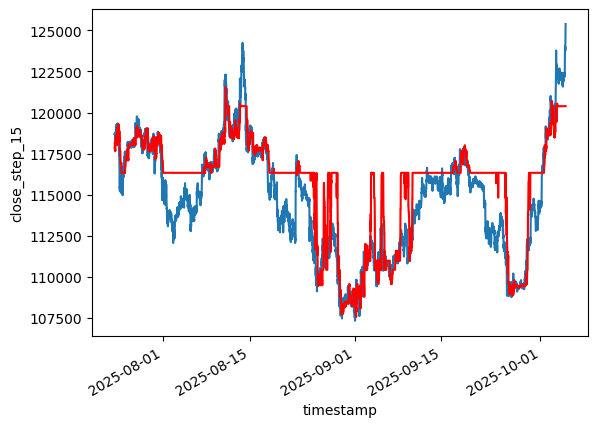

[0]	validation_0-rmse:15341.61432
[1]	validation_0-rmse:14616.19959
[2]	validation_0-rmse:13918.57505
[3]	validation_0-rmse:13253.04072
[4]	validation_0-rmse:12636.06191
[5]	validation_0-rmse:12054.88031
[6]	validation_0-rmse:11478.44418
[7]	validation_0-rmse:10932.51383
[8]	validation_0-rmse:10405.12299
[9]	validation_0-rmse:9900.13487
[10]	validation_0-rmse:9420.88303
[11]	validation_0-rmse:8986.12991
[12]	validation_0-rmse:8552.09761
[13]	validation_0-rmse:8160.66388
[14]	validation_0-rmse:7766.02096
[15]	validation_0-rmse:7391.21312
[16]	validation_0-rmse:7035.82463
[17]	validation_0-rmse:6711.86562
[18]	validation_0-rmse:6388.14332
[19]	validation_0-rmse:6081.41539
[20]	validation_0-rmse:5793.17514
[21]	validation_0-rmse:5519.22059
[22]	validation_0-rmse:5270.30240
[23]	validation_0-rmse:5032.35702
[24]	validation_0-rmse:4793.57654
[25]	validation_0-rmse:4569.75598
[26]	validation_0-rmse:4360.72570
[27]	validation_0-rmse:4156.85893
[28]	validation_0-rmse:3962.38047
[29]	validation

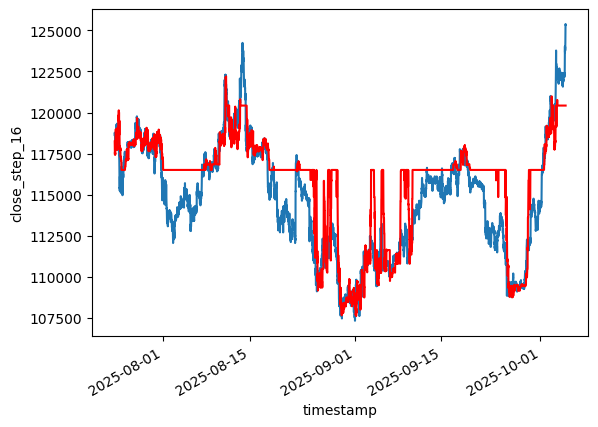

In [51]:
for target in TARGET:
    X_close_train = close_train[features_by_target[target]]
    y_close_train = close_train[target]
    X_close_test = close_test[features_by_target[target]]
    y_close_test = close_test[target]
    
    split_point = int(len(X_close_train) * 0.8)
    X_train_split = X_close_train[:split_point]
    y_train_split = y_close_train[:split_point]
    X_val_split = X_close_train[split_point:]
    y_val_split = y_close_train[split_point:]

    xgb_open_close = XGBRegressor(
        objective='reg:squarederror', 
        **parameters_by_target[target],
        eval_metric="rmse",
        early_stopping_rounds=100,
        device='cuda', 
        max_bin=256 
        )

    xgb_open_close.fit(
        X_close_train, 
        y_close_train,
        eval_set=[(X_val_split, y_val_split)]
    )
    y_pred = xgb_open_close.predict(X_close_test)
    

    print(f"Performance metrics for {target}:")
    mse = mean_squared_error(y_close_test, y_pred)
    rmse = root_mean_squared_error(y_close_test, y_pred)
    mae = mean_absolute_error(y_close_test, y_pred)
    r2 = r2_score(y_close_test, y_pred)

    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2 Score): {r2:.2f}")

    
    model_filename = f"{model_folder}/xgb_model_{target}.joblib"
    joblib.dump(xgb_open_close, model_filename)
    print(f"✓ Model saved to: {model_filename}")

    dataset_compare = close_test.copy()
    dataset_compare[f'{target}_pred'] = y_pred

    sns.lineplot(x="timestamp", y=target, data=dataset_compare)
    sns.lineplot(x="timestamp", y=f'{target}_pred', data=dataset_compare, color="red")
    plt.gcf().autofmt_xdate()
    plt.show()

In [ ]:
import xgboost as xgb
from xgboost import XGBRegressor

# Check XGBoost build info
print(xgb.__version__)
print(xgb.config.get_config())

# Try to use GPU and catch any errors
try:
    model = XGBRegressor(tree_method='gpu_hist')
    print("✓ GPU support is available!")
except Exception as e:
    print(f"✗ GPU not available: {e}")

3.0.4
{'nthread': 0, 'use_rmm': False, 'verbosity': 1}
✓ GPU support is available!
